In [ ]:
import pandas as pd

gpu_df = pd.read_csv('hardware_data.csv')
cpu_df = pd.read_csv('cpu_data.csv')


gpu_df.head()

,Component_Type,Brand,Full_Model_Name,Series_Generation,Suffix_Type,MSRP_Price,Current_Street_Price,VRAM_GB,G3D_Mark,Price_per_Mark
0,GPU,Nvidia,GeForce RTX 5080,50,NaN,999,1500.00,16,35900,0.042
1,GPU,AMD,Radeon RX 7900 XTX,79,XTX,999,999.00,24,31100,0.032
2,GPU,Nvidia,GeForce RTX 5070 Ti,50,Ti,749,1199.99,16,32367,0.037
3,GPU,AMD,Radeon RX 9070 XT,90,XT,599,799.50,16,27183,0.029
4,GPU,Nvidia,GeForce RTX 5070,50,NaN,549,979.65,12,28679,0.034


In [2]:
cpu_df.head()

,Component_Type,Brand,Full_Model_Name,Price,Cores,Threads,TDP_W,CPU_Mark,Price_per_Mark,Gaming_Adv_1080p_Pct,Gaming_Adv_1440p_Pct,Gaming_Adv_4K_Pct,Notes
CPU,AMD,Ryzen 7 9800X3D,449.0,8,16,120,39977,0.011,24.0,6.0,2.0,Best-in-class gaming CPU (3D V-Cache); CPU_Mar...,not a single formal test)
CPU,Intel,Core Ultra 9 285K,579.0,24,24,125,67300,0.009,NaN,NaN,NaN,Wins CPU_Mark (multi-core work) but loses in r...,NaN
CPU,AMD,Ryzen 7 9700X,303.0,8,16,65,37049,0.008,NaN,NaN,NaN,Resolution-scaling data not yet gathered for t...,NaN
CPU,Intel,Core Ultra 7 265K,315.0,20,20,125,58678,0.005,NaN,NaN,NaN,Resolution-scaling data not yet gathered for t...,NaN
CPU,AMD,Ryzen 5 7600,199.0,6,12,65,26977,0.007,NaN,NaN,NaN,Resolution-scaling data not yet gathered for t...,NaN


In [3]:
gpu_df.info()
print("---")
cpu_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Component_Type        16 non-null     str    
 1   Brand                 16 non-null     str    
 2   Full_Model_Name       16 non-null     str    
 3   Series_Generation     16 non-null     int64  
 4   Suffix_Type           9 non-null      str    
 5   MSRP_Price            16 non-null     int64  
 6   Current_Street_Price  16 non-null     float64
 7   VRAM_GB               16 non-null     int64  
 8   G3D_Mark              16 non-null     int64  
 9   Price_per_Mark        16 non-null     float64
dtypes: float64(2), int64(4), str(4)
memory usage: 1.4 KB
---
<class 'pandas.DataFrame'>
Index: 6 entries, CPU to CPU
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Component_Type        6 non-null      

In [4]:
gpu_df.sort_values('Price_per_Mark')

,Component_Type,Brand,Full_Model_Name,Series_Generation,Suffix_Type,MSRP_Price,Current_Street_Price,VRAM_GB,G3D_Mark,Price_per_Mark
10,GPU,Nvidia,GeForce RTX 4060 Ti,40,Ti,399,325.00,8,22608,0.014
14,GPU,Nvidia,GeForce RTX 4060,40,NaN,299,299.99,8,19700,0.015
15,GPU,AMD,Radeon RX 7600,76,NaN,269,259.99,8,16611,0.016
12,GPU,Nvidia,GeForce RTX 5060,50,NaN,299,329.00,8,20660,0.016
13,GPU,AMD,Radeon RX 9060 XT,90,XT,349,430.00,16,20088,0.021
9,GPU,AMD,Radeon RX 7800 XT,78,XT,499,519.99,16,24207,0.021
7,GPU,AMD,Radeon RX 7900 XT,79,XT,899,699.99,20,28900,0.024
11,GPU,AMD,Radeon RX 7700 XT,77,XT,449,529.99,12,22448,0.024
5,GPU,AMD,Radeon RX 9070,90,NaN,549,689.99,16,26166,0.026
3,GPU,AMD,Radeon RX 9070 XT,90,XT,599,799.50,16,27183,0.029


In [5]:
gpu_df.groupby('Brand')['Price_per_Mark'].mean()

Brand
AMD       0.024125
Nvidia    0.029000
Name: Price_per_Mark, dtype: float64

In [6]:
budget_gpus = gpu_df[gpu_df['Current_Street_Price'] < 500]
budget_gpus.sort_values('Price_per_Mark')

,Component_Type,Brand,Full_Model_Name,Series_Generation,Suffix_Type,MSRP_Price,Current_Street_Price,VRAM_GB,G3D_Mark,Price_per_Mark
10,GPU,Nvidia,GeForce RTX 4060 Ti,40,Ti,399,325.00,8,22608,0.014
14,GPU,Nvidia,GeForce RTX 4060,40,NaN,299,299.99,8,19700,0.015
12,GPU,Nvidia,GeForce RTX 5060,50,NaN,299,329.00,8,20660,0.016
15,GPU,AMD,Radeon RX 7600,76,NaN,269,259.99,8,16611,0.016
13,GPU,AMD,Radeon RX 9060 XT,90,XT,349,430.00,16,20088,0.021


In [7]:
cpu_df.sort_values('Price_per_Mark')

,Component_Type,Brand,Full_Model_Name,Price,Cores,Threads,TDP_W,CPU_Mark,Price_per_Mark,Gaming_Adv_1080p_Pct,Gaming_Adv_1440p_Pct,Gaming_Adv_4K_Pct,Notes
CPU,AMD,Ryzen 7 9800X3D,449.0,8,16,120,39977,0.011,24.0,6.0,2.0,Best-in-class gaming CPU (3D V-Cache); CPU_Mar...,not a single formal test)
CPU,Intel,Core Ultra 9 285K,579.0,24,24,125,67300,0.009,NaN,NaN,NaN,Wins CPU_Mark (multi-core work) but loses in r...,NaN
CPU,AMD,Ryzen 7 9700X,303.0,8,16,65,37049,0.008,NaN,NaN,NaN,Resolution-scaling data not yet gathered for t...,NaN
CPU,Intel,Core Ultra 7 265K,315.0,20,20,125,58678,0.005,NaN,NaN,NaN,Resolution-scaling data not yet gathered for t...,NaN
CPU,AMD,Ryzen 5 7600,199.0,6,12,65,26977,0.007,NaN,NaN,NaN,Resolution-scaling data not yet gathered for t...,NaN
CPU,Intel,Core i5-14600K,210.0,14,20,125,38449,0.005,NaN,NaN,NaN,Resolution-scaling data not yet gathered for t...,NaN


In [ ]:
import numpy as np

# price tier buckets
gpu_df['Price_Tier'] = pd.cut(gpu_df['Current_Street_Price'], 
                                bins=[0, 350, 700, 2000], 
                                labels=['Budget', 'Mid-range', 'High-end'])

# Comparing the brands within tier
gpu_df.groupby(['Price_Tier', 'Brand'])['Price_per_Mark'].mean()

Price_Tier  Brand 
Budget      AMD       0.01600
            Nvidia    0.01500
Mid-range   AMD       0.02320
            Nvidia    0.03400
High-end    AMD       0.03050
            Nvidia    0.03825
Name: Price_per_Mark, dtype: float64

In [9]:
budget_tier = gpu_df[gpu_df['Price_Tier'] == 'Budget']
budget_tier[['Full_Model_Name', 'Current_Street_Price', 'VRAM_GB', 'G3D_Mark', 'Price_per_Mark']].sort_values('Price_per_Mark')

,Full_Model_Name,Current_Street_Price,VRAM_GB,G3D_Mark,Price_per_Mark
10,GeForce RTX 4060 Ti,325.00,8,22608,0.014
14,GeForce RTX 4060,299.99,8,19700,0.015
12,GeForce RTX 5060,329.00,8,20660,0.016
15,Radeon RX 7600,259.99,8,16611,0.016


In [10]:
budget_tier = budget_tier.copy()
budget_tier['VRAM_per_Dollar'] = budget_tier['VRAM_GB'] / budget_tier['Current_Street_Price']
budget_tier[['Full_Model_Name', 'Price_per_Mark', 'VRAM_per_Dollar']].sort_values('VRAM_per_Dollar', ascending=False)

,Full_Model_Name,Price_per_Mark,VRAM_per_Dollar
15,Radeon RX 7600,0.016,0.030770
14,GeForce RTX 4060,0.015,0.026668
10,GeForce RTX 4060 Ti,0.014,0.024615
12,GeForce RTX 5060,0.016,0.024316


In [11]:
# THIS IS JUST FOR MY OWN COMPARISON FOR MY NEW BUILD###

compare = gpu_df[gpu_df['Full_Model_Name'].isin(['GeForce RTX 4060', 'Radeon RX 7600', 'GeForce RTX 5060', 'Radeon RX 9060 XT'])]
compare[['Full_Model_Name', 'Current_Street_Price', 'VRAM_GB', 'Price_per_Mark']].sort_values('Price_per_Mark')

,Full_Model_Name,Current_Street_Price,VRAM_GB,Price_per_Mark
14,GeForce RTX 4060,299.99,8,0.015
12,GeForce RTX 5060,329.00,8,0.016
15,Radeon RX 7600,259.99,8,0.016
13,Radeon RX 9060 XT,430.00,16,0.021


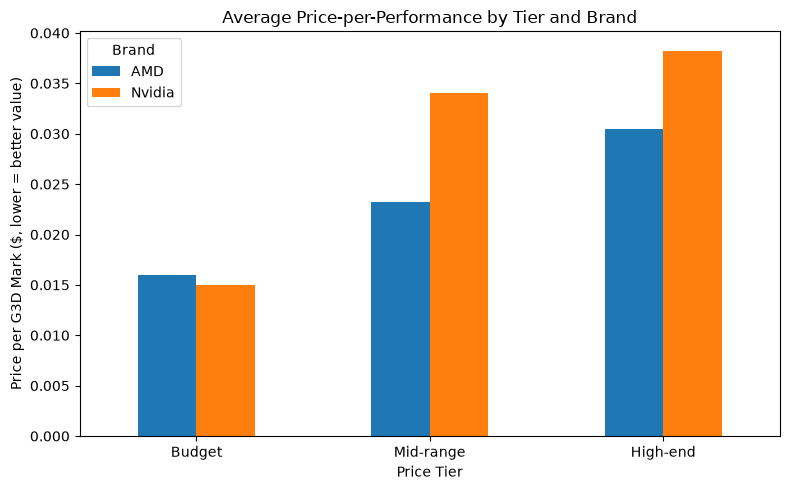

In [13]:
import matplotlib.pyplot as plt

tier_compare = gpu_df.groupby(['Price_Tier', 'Brand'])['Price_per_Mark'].mean().unstack()
tier_compare.plot(kind='bar', figsize=(8,5))
plt.title('Average Price-per-Performance by Tier and Brand')
plt.ylabel('Price per G3D Mark ($, lower = better value)')
plt.xlabel('Price Tier')
plt.xticks(rotation=0)
plt.legend(title='Brand')
plt.tight_layout()
plt.show()

C:\Users\Blake Evans\AppData\Local\Temp\ipykernel_21256\3530844092.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(compare['Full_Model_Name'], rotation=20, ha='right')


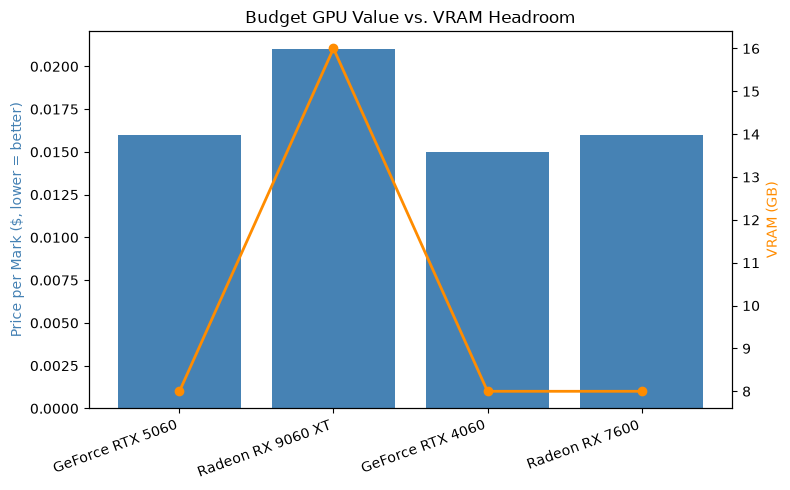

In [14]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(compare['Full_Model_Name'], compare['Price_per_Mark'], color='steelblue', label='Price per Mark')
ax1.set_ylabel('Price per Mark ($, lower = better)', color='steelblue')
ax1.set_xticklabels(compare['Full_Model_Name'], rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(compare['Full_Model_Name'], compare['VRAM_GB'], color='darkorange', marker='o', linewidth=2, label='VRAM (GB)')
ax2.set_ylabel('VRAM (GB)', color='darkorange')

plt.title('Budget GPU Value vs. VRAM Headroom')
fig.tight_layout()
plt.show()

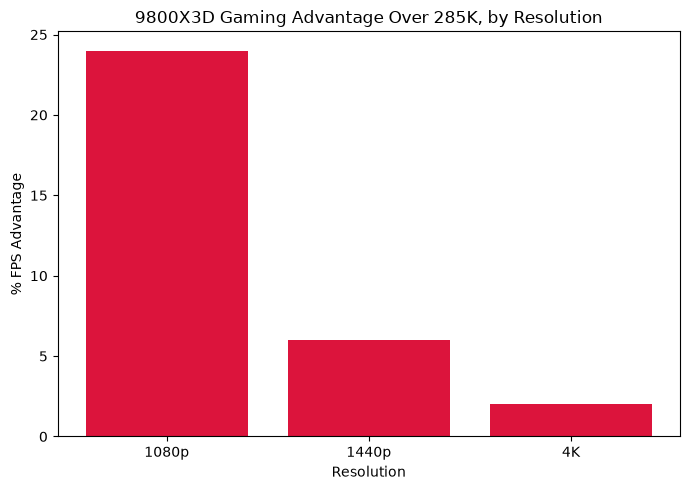

In [15]:
resolutions = ['1080p', '1440p', '4K']
advantage = [24, 6, 2]

plt.figure(figsize=(7,5))
plt.bar(resolutions, advantage, color='crimson')
plt.title('9800X3D Gaming Advantage Over 285K, by Resolution')
plt.ylabel('% FPS Advantage')
plt.xlabel('Resolution')
plt.tight_layout()
plt.show()